# Standarisasi Dataset Jeruk

Notebook ini khusus untuk tahap **standarisasi dataset**, yaitu:
1. Membaca dataset asli dari Google Drive.
2. Menghitung jumlah gambar per kelas.
3. Menghapus folder output lama agar tidak tercampur file lama.
4. Mengonversi semua gambar ke format **JPG**.
5. Mengubah mode warna menjadi **RGB**.
6. Memperbaiki orientasi gambar berdasarkan metadata EXIF.
7. Mengubah ukuran gambar menjadi **224 × 224 piksel**.
8. Mengganti nama file menjadi rapi dan konsisten.
9. Menyimpan log konversi ke CSV.
10. Mengecek ulang jumlah, ukuran, mode warna, dan file gagal.

Struktur input yang digunakan:

```text
MyDrive/dataset_jeruk_UAS/dataset-jeruk-asli/
├── belum_matang/
└── matang/
```

Struktur output yang akan dibuat otomatis:

```text
MyDrive/dataset_jeruk_UAS/dataset-jeruk-standarisasi/
├── belum_matang/
├── matang/
└── conversion_log.csv
```

## 1. Install Library

Jalankan cell ini terlebih dahulu.  
Library `pillow-heif` digunakan agar file **HEIC/HEIF** dari HP dapat dibaca dan dikonversi.

In [ ]:
!pip install -q pillow pillow-heif tqdm pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 13.3 MB/s eta 0:00:00


## 2. Mount Google Drive

Cell ini digunakan untuk menghubungkan Google Colab dengan Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Konfigurasi Path dan Parameter

Pastikan path berikut sesuai dengan folder Google Drive .

Dataset asli berada di:

```text
/content/drive/MyDrive/dataset_jeruk_UAS/dataset-jeruk-asli
```

Dataset hasil standarisasi akan disimpan ke:

```text
/content/drive/MyDrive/dataset_jeruk_UAS/dataset-jeruk-standarisasi
```

Pada notebook ini, gambar distandarisasi menjadi **JPG, RGB, 224×224 piksel**.

In [ ]:
from pathlib import Path

BASE_DRIVE_DIR = Path("/content/drive/MyDrive/dataset_jeruk_UAS")

RAW_DATA_DIR = BASE_DRIVE_DIR / "dataset-jeruk-asli"
STANDARDIZED_DATA_DIR = BASE_DRIVE_DIR / "dataset-jeruk-standarisasi"

CLASS_NAMES = ["belum_matang", "matang"]

IMAGE_PREFIX = "jeruk"
JPEG_QUALITY = 95
TARGET_SIZE = (224, 224)

SUPPORTED_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".heic", ".heif", ".webp", ".bmp", ".tif", ".tiff"
}

print("Raw dataset path          :", RAW_DATA_DIR)
print("Standardized dataset path :", STANDARDIZED_DATA_DIR)
print("Class names               :", CLASS_NAMES)
print("Target image size         :", TARGET_SIZE)
print("JPEG quality              :", JPEG_QUALITY)

Raw dataset path          : /content/drive/MyDrive/dataset_jeruk_UAS/dataset-jeruk-asli
Standardized dataset path : /content/drive/MyDrive/dataset_jeruk_UAS/dataset-jeruk-standarisasi
Class names               : ['belum_matang', 'matang']
Target image size         : (224, 224)
JPEG quality              : 95


## 4. Cek Struktur Folder Dataset Asli

Cell ini memastikan folder dataset asli dan folder kelas sudah ada.

In [ ]:
print("RAW_DATA_DIR exists:", RAW_DATA_DIR.exists())

if RAW_DATA_DIR.exists():
    print("\nIsi folder dataset asli:")
    for item in RAW_DATA_DIR.iterdir():
        print("-", item.name)
else:
    print("Folder dataset asli tidak ditemukan. Periksa kembali RAW_DATA_DIR.")

for class_name in CLASS_NAMES:
    class_dir = RAW_DATA_DIR / class_name
    print(f"Folder {class_name} exists:", class_dir.exists(), "|", class_dir)

RAW_DATA_DIR exists: True

Isi folder dataset asli:
- matang
- belum_matang
Folder belum_matang exists: True | /content/drive/MyDrive/dataset_jeruk_UAS/dataset-jeruk-asli/belum_matang
Folder matang exists: True | /content/drive/MyDrive/dataset_jeruk_UAS/dataset-jeruk-asli/matang


## 5. Hitung Jumlah Gambar Dataset Asli

Cell ini menghitung jumlah file gambar pada masing-masing kelas sebelum proses standarisasi.

Jika dataset terbaru benar berisi:
- `belum_matang`: 235 gambar
- `matang`: 245 gambar

maka hasil cell ini harus menampilkan angka tersebut.

In [ ]:
def get_image_files(folder_path: Path):
    if not folder_path.exists():
        return []

    image_files = [
        file for file in folder_path.iterdir()
        if file.is_file() and file.suffix.lower() in SUPPORTED_EXTENSIONS
    ]

    return sorted(image_files)


raw_count_summary = {}

for class_name in CLASS_NAMES:
    class_dir = RAW_DATA_DIR / class_name
    image_files = get_image_files(class_dir)
    raw_count_summary[class_name] = len(image_files)

    print(f"{class_name}: {len(image_files)} raw images")
    print("Contoh 5 file:", [file.name for file in image_files[:5]])
    print()

print("Total raw images:", sum(raw_count_summary.values()))

belum_matang: 235 raw images
Contoh 5 file: ['20220708_180017.jpg', '20220708_180036.jpg', '20220708_180041.jpg', '20220708_180127.jpg', '20220708_180132.jpg']

matang: 245 raw images
Contoh 5 file: ['20220708_175250.jpg', '20220708_175300.jpg', '20220708_175442.jpg', '20220708_175641.jpg', '20220708_175701.jpg']

Total raw images: 480


## 6. Bersihkan Folder Output Standarisasi

Cell ini akan menghapus folder `dataset-jeruk-standarisasi` jika sudah ada.

Tujuannya agar hasil standarisasi baru **tidak tercampur** dengan file lama dari proses sebelumnya.

> Jalankan cell ini setiap kali ingin melakukan standarisasi ulang dari awal.

In [ ]:
import shutil

if STANDARDIZED_DATA_DIR.exists():
    shutil.rmtree(STANDARDIZED_DATA_DIR)

STANDARDIZED_DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Folder output standarisasi sudah dibersihkan dan dibuat ulang:")
print(STANDARDIZED_DATA_DIR)

Folder output standarisasi sudah dibersihkan dan dibuat ulang:
/content/drive/MyDrive/dataset_jeruk_UAS/dataset-jeruk-standarisasi


## 7. Fungsi Standarisasi Gambar

Fungsi ini melakukan:
- membuka gambar dari dataset asli,
- memperbaiki orientasi EXIF,
- mengubah gambar ke RGB,
- resize menjadi 224×224 piksel,
- menyimpan sebagai JPG.

Resize dilakukan saat standarisasi agar semua gambar memiliki ukuran konsisten untuk **MobileNetV3Large** dan ekstraksi fitur **RGB+HSV** pada SVM.

In [ ]:
from PIL import Image, ImageOps
from pillow_heif import register_heif_opener
from tqdm import tqdm
import pandas as pd

register_heif_opener(thumbnails=False)


def convert_to_rgb_and_resize(image: Image.Image, target_size: tuple[int, int]) -> Image.Image:
    '''
    Convert image to RGB, fix EXIF orientation, and resize to target size.

    Direct resize is used so every image has the same pixel dimension.
    This is useful for CNN input and consistent RGB/HSV feature extraction.
    '''
    image = ImageOps.exif_transpose(image)

    if image.mode in ("RGBA", "LA"):
        background = Image.new("RGB", image.size, (255, 255, 255))
        alpha_channel = image.getchannel("A")
        background.paste(image.convert("RGBA"), mask=alpha_channel)
        image = background
    else:
        image = image.convert("RGB")

    image = image.resize(target_size, Image.Resampling.LANCZOS)

    return image


def standardize_dataset(
    raw_data_dir: Path,
    output_data_dir: Path,
    class_names: list[str],
    image_prefix: str = "jeruk",
    target_size: tuple[int, int] = (224, 224),
    jpeg_quality: int = 95
) -> pd.DataFrame:
    '''
    Standardize all images from raw_data_dir into JPG RGB target_size images.

    Output filenames:
    jeruk_001_belum_matang.jpg
    jeruk_002_belum_matang.jpg
    ...
    jeruk_001_matang.jpg
    jeruk_002_matang.jpg
    ...
    '''
    output_data_dir.mkdir(parents=True, exist_ok=True)

    conversion_logs = []

    for class_name in class_names:
        input_class_dir = raw_data_dir / class_name
        output_class_dir = output_data_dir / class_name
        output_class_dir.mkdir(parents=True, exist_ok=True)

        image_files = get_image_files(input_class_dir)

        print(f"\nProcessing class: {class_name}")
        print(f"Input folder : {input_class_dir}")
        print(f"Output folder: {output_class_dir}")
        print(f"Total images : {len(image_files)}")

        if len(image_files) == 0:
            print(f"[WARNING] No images found in {input_class_dir}")
            continue

        for index, image_path in enumerate(tqdm(image_files, desc=f"Standardizing {class_name}"), start=1):
            new_filename = f"{image_prefix}_{index:03d}_{class_name}.jpg"
            output_path = output_class_dir / new_filename

            try:
                with Image.open(image_path) as image:
                    original_width, original_height = image.size
                    original_mode = image.mode
                    original_format = image.format

                    processed_image = convert_to_rgb_and_resize(
                        image=image,
                        target_size=target_size
                    )

                    processed_image.save(
                        output_path,
                        format="JPEG",
                        quality=jpeg_quality,
                        optimize=True
                    )

                conversion_logs.append({
                    "class_name": class_name,
                    "old_file_name": image_path.name,
                    "old_file_path": str(image_path),
                    "old_extension": image_path.suffix.lower(),
                    "old_width": original_width,
                    "old_height": original_height,
                    "old_mode": original_mode,
                    "old_format": original_format,
                    "new_file_name": new_filename,
                    "new_file_path": str(output_path),
                    "new_width": target_size[0],
                    "new_height": target_size[1],
                    "new_mode": "RGB",
                    "new_format": "JPEG",
                    "status": "success"
                })

            except Exception as error:
                conversion_logs.append({
                    "class_name": class_name,
                    "old_file_name": image_path.name,
                    "old_file_path": str(image_path),
                    "old_extension": image_path.suffix.lower(),
                    "old_width": "",
                    "old_height": "",
                    "old_mode": "",
                    "old_format": "",
                    "new_file_name": "",
                    "new_file_path": "",
                    "new_width": "",
                    "new_height": "",
                    "new_mode": "",
                    "new_format": "",
                    "status": f"failed: {error}"
                })

                print(f"[FAILED] {image_path.name} | Error: {error}")

    log_df = pd.DataFrame(conversion_logs)
    log_path = output_data_dir / "conversion_log.csv"
    log_df.to_csv(log_path, index=False)

    print("\nStandardization completed.")
    print(f"Conversion log saved to: {log_path}")

    return log_df

## 8. Jalankan Standarisasi Dataset

Cell ini menjalankan proses konversi dan resize untuk semua gambar.

Output akan tersimpan di:

```text
dataset-jeruk-standarisasi/
├── belum_matang/
├── matang/
└── conversion_log.csv
```

In [ ]:
log_df = standardize_dataset(
    raw_data_dir=RAW_DATA_DIR,
    output_data_dir=STANDARDIZED_DATA_DIR,
    class_names=CLASS_NAMES,
    image_prefix=IMAGE_PREFIX,
    target_size=TARGET_SIZE,
    jpeg_quality=JPEG_QUALITY
)

display(log_df.head())


Processing class: belum_matang
Input folder : /content/drive/MyDrive/dataset_jeruk_UAS/dataset-jeruk-asli/belum_matang
Output folder: /content/drive/MyDrive/dataset_jeruk_UAS/dataset-jeruk-standarisasi/belum_matang
Total images : 235


Standardizing belum_matang: 100%|██████████| 235/235 [01:24<00:00,  2.77it/s]



Processing class: matang
Input folder : /content/drive/MyDrive/dataset_jeruk_UAS/dataset-jeruk-asli/matang
Output folder: /content/drive/MyDrive/dataset_jeruk_UAS/dataset-jeruk-standarisasi/matang
Total images : 245


Standardizing matang: 100%|██████████| 245/245 [01:03<00:00,  3.89it/s]


Standardization completed.
Conversion log saved to: /content/drive/MyDrive/dataset_jeruk_UAS/dataset-jeruk-standarisasi/conversion_log.csv


,class_name,old_file_name,old_file_path,old_extension,old_width,old_height,old_mode,old_format,new_file_name,new_file_path,new_width,new_height,new_mode,new_format,status
0,belum_matang,20220708_180017.jpg,/content/drive/MyDrive/dataset_jeruk_UAS/datas...,.jpg,3472,3472,RGB,JPEG,jeruk_001_belum_matang.jpg,/content/drive/MyDrive/dataset_jeruk_UAS/datas...,224,224,RGB,JPEG,success
1,belum_matang,20220708_180036.jpg,/content/drive/MyDrive/dataset_jeruk_UAS/datas...,.jpg,3472,3472,RGB,JPEG,jeruk_002_belum_matang.jpg,/content/drive/MyDrive/dataset_jeruk_UAS/datas...,224,224,RGB,JPEG,success
2,belum_matang,20220708_180041.jpg,/content/drive/MyDrive/dataset_jeruk_UAS/datas...,.jpg,3472,3472,RGB,JPEG,jeruk_003_belum_matang.jpg,/content/drive/MyDrive/dataset_jeruk_UAS/datas...,224,224,RGB,JPEG,success
3,belum_matang,20220708_180127.jpg,/content/drive/MyDrive/dataset_jeruk_UAS/datas...,.jpg,3472,3472,RGB,JPEG,jeruk_004_belum_matang.jpg,/content/drive/MyDrive/dataset_jeruk_UAS/datas...,224,224,RGB,JPEG,success
4,belum_matang,20220708_180132.jpg,/content/drive/MyDrive/dataset_jeruk_UAS/datas...,.jpg,3472,3472,RGB,JPEG,jeruk_005_belum_matang.jpg,/content/drive/MyDrive/dataset_jeruk_UAS/datas...,224,224,RGB,JPEG,success


## 9. Cek File yang Gagal Diproses

Cell ini menampilkan daftar file yang gagal dikonversi.

Jika hasilnya `0`, berarti semua file berhasil distandarisasi.

In [ ]:
failed_df = log_df[log_df["status"] != "success"]

print("Total failed files:", len(failed_df))

display(failed_df)

Total failed files: 0


,class_name,old_file_name,old_file_path,old_extension,old_width,old_height,old_mode,old_format,new_file_name,new_file_path,new_width,new_height,new_mode,new_format,status


## 10. Cek Jumlah Gambar Hasil Standarisasi

Jumlah hasil standarisasi harus sama dengan jumlah dataset asli.

Jika dataset asli:
- `belum_matang`: 235
- `matang`: 245

maka output ideal:
- `belum_matang`: 235 standardized images
- `matang`: 245 standardized images

In [ ]:
def count_standardized_images(folder_path: Path):
    if not folder_path.exists():
        return 0

    return len([
        file for file in folder_path.iterdir()
        if file.is_file() and file.suffix.lower() == ".jpg"
    ])


standardized_count_summary = {}

for class_name in CLASS_NAMES:
    class_dir = STANDARDIZED_DATA_DIR / class_name
    total_images = count_standardized_images(class_dir)
    standardized_count_summary[class_name] = total_images

    print(f"{class_name}: {total_images} standardized images")

print("Total standardized images:", sum(standardized_count_summary.values()))

belum_matang: 235 standardized images
matang: 245 standardized images
Total standardized images: 480


## 11. Bandingkan Jumlah Raw dan Standarisasi

Cell ini memastikan jumlah gambar raw dan output sama.

Jika ada perbedaan, berarti ada file yang gagal diproses atau folder output belum bersih.

In [ ]:
comparison_records = []

for class_name in CLASS_NAMES:
    raw_count = raw_count_summary.get(class_name, 0)
    standardized_count = standardized_count_summary.get(class_name, 0)

    comparison_records.append({
        "class_name": class_name,
        "raw_count": raw_count,
        "standardized_count": standardized_count,
        "difference": raw_count - standardized_count,
        "is_match": raw_count == standardized_count
    })

comparison_df = pd.DataFrame(comparison_records)

display(comparison_df)

if comparison_df["is_match"].all():
    print("Jumlah raw dan hasil standarisasi sudah sesuai.")
else:
    print("Masih ada jumlah yang tidak sesuai. Cek failed_df atau folder output.")

,class_name,raw_count,standardized_count,difference,is_match
0,belum_matang,235,235,0,True
1,matang,245,245,0,True


Jumlah raw dan hasil standarisasi sudah sesuai.


## 12. Cek Ukuran, Mode Warna, dan Format Gambar Output

Semua gambar hasil standarisasi harus:
- `width = 224`
- `height = 224`
- `mode = RGB`
- `format = JPEG`

In [ ]:
from PIL import Image

size_records = []

for class_name in CLASS_NAMES:
    class_dir = STANDARDIZED_DATA_DIR / class_name
    image_files = sorted(class_dir.glob("*.jpg"))

    for image_path in image_files:
        try:
            with Image.open(image_path) as img:
                size_records.append({
                    "class_name": class_name,
                    "file_name": image_path.name,
                    "width": img.width,
                    "height": img.height,
                    "mode": img.mode,
                    "format": img.format
                })
        except Exception as error:
            size_records.append({
                "class_name": class_name,
                "file_name": image_path.name,
                "width": "",
                "height": "",
                "mode": "",
                "format": "",
                "error": str(error)
            })

size_df = pd.DataFrame(size_records)

if size_df.empty:
    print("Tidak ada gambar yang terbaca.")
else:
    print("Ringkasan ukuran dan mode gambar:")
    print(size_df.groupby(["class_name", "width", "height", "mode", "format"]).size())

    display(size_df.head())

Ringkasan ukuran dan mode gambar:
class_name    width  height  mode  format
belum_matang  224    224     RGB   JPEG      235
matang        224    224     RGB   JPEG      245
dtype: int64


,class_name,file_name,width,height,mode,format
0,belum_matang,jeruk_001_belum_matang.jpg,224,224,RGB,JPEG
1,belum_matang,jeruk_002_belum_matang.jpg,224,224,RGB,JPEG
2,belum_matang,jeruk_003_belum_matang.jpg,224,224,RGB,JPEG
3,belum_matang,jeruk_004_belum_matang.jpg,224,224,RGB,JPEG
4,belum_matang,jeruk_005_belum_matang.jpg,224,224,RGB,JPEG


## 13. Cek Apakah Ada Gambar Output yang Tidak Sesuai Standar

Cell ini mencari file yang tidak memenuhi standar:
- bukan 224×224
- bukan RGB
- bukan JPEG

In [ ]:
invalid_size_df = size_df[
    (size_df["width"] != TARGET_SIZE[0]) |
    (size_df["height"] != TARGET_SIZE[1]) |
    (size_df["mode"] != "RGB") |
    (size_df["format"] != "JPEG")
]

print("Total invalid standardized images:", len(invalid_size_df))

display(invalid_size_df)

Total invalid standardized images: 0


,class_name,file_name,width,height,mode,format


## 14. Cek Nama File Output

Nama file hasil standarisasi harus konsisten, contohnya:

```text
jeruk_001_belum_matang.jpg
jeruk_002_belum_matang.jpg
jeruk_001_matang.jpg
```

Cell ini menampilkan beberapa contoh nama file dari masing-masing kelas.

In [ ]:
for class_name in CLASS_NAMES:
    class_dir = STANDARDIZED_DATA_DIR / class_name
    image_files = sorted(class_dir.glob("*.jpg"))

    print(f"\n{class_name}")
    print("Total:", len(image_files))
    print("Contoh 10 file:")
    for file in image_files[:10]:
        print("-", file.name)


belum_matang
Total: 235
Contoh 10 file:
- jeruk_001_belum_matang.jpg
- jeruk_002_belum_matang.jpg
- jeruk_003_belum_matang.jpg
- jeruk_004_belum_matang.jpg
- jeruk_005_belum_matang.jpg
- jeruk_006_belum_matang.jpg
- jeruk_007_belum_matang.jpg
- jeruk_008_belum_matang.jpg
- jeruk_009_belum_matang.jpg
- jeruk_010_belum_matang.jpg

matang
Total: 245
Contoh 10 file:
- jeruk_001_matang.jpg
- jeruk_002_matang.jpg
- jeruk_003_matang.jpg
- jeruk_004_matang.jpg
- jeruk_005_matang.jpg
- jeruk_006_matang.jpg
- jeruk_007_matang.jpg
- jeruk_008_matang.jpg
- jeruk_009_matang.jpg
- jeruk_010_matang.jpg


## 15. Tampilkan Contoh Gambar Hasil Standarisasi

Cell ini menampilkan beberapa gambar hasil standarisasi untuk memastikan gambar masih terbaca dengan baik.

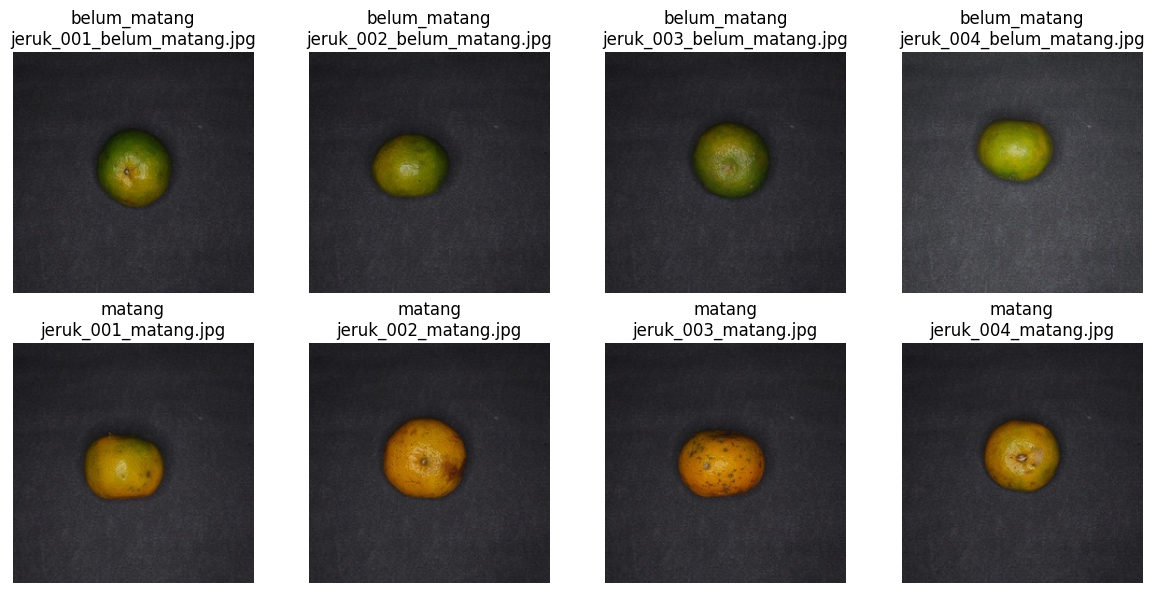

In [ ]:
import matplotlib.pyplot as plt

sample_images = []

for class_name in CLASS_NAMES:
    class_dir = STANDARDIZED_DATA_DIR / class_name
    image_files = sorted(class_dir.glob("*.jpg"))
    sample_images.extend([(class_name, path) for path in image_files[:4]])

plt.figure(figsize=(12, 6))

for i, (class_name, image_path) in enumerate(sample_images):
    image = Image.open(image_path).convert("RGB")

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(f"{class_name}\n{image_path.name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 16.Ringkasan Standarisasi untuk Laporan

Cell ini membuat file `standardization_summary.csv` yang berisi:
- jumlah data asli,
- jumlah data hasil standarisasi,
- ukuran target,
- status kesesuaian jumlah.

In [ ]:
summary_records = []

for class_name in CLASS_NAMES:
    summary_records.append({
        "class_name": class_name,
        "raw_count": raw_count_summary.get(class_name, 0),
        "standardized_count": standardized_count_summary.get(class_name, 0),
        "target_width": TARGET_SIZE[0],
        "target_height": TARGET_SIZE[1],
        "format": "JPG/JPEG",
        "color_mode": "RGB",
        "count_match": raw_count_summary.get(class_name, 0) == standardized_count_summary.get(class_name, 0)
    })

summary_df = pd.DataFrame(summary_records)
summary_path = STANDARDIZED_DATA_DIR / "standardization_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("Standardization summary saved to:", summary_path)
display(summary_df)

Standardization summary saved to: /content/drive/MyDrive/dataset_jeruk_UAS/dataset-jeruk-standarisasi/standardization_summary.csv


,class_name,raw_count,standardized_count,target_width,target_height,format,color_mode,count_match
0,belum_matang,235,235,224,224,JPG/JPEG,RGB,True
1,matang,245,245,224,224,JPG/JPEG,RGB,True
